# EDA 06: Somatic Mutations

## Purpose

`6_OmicsSomaticMutationsProfile.csv` is an **event table** (like fusions) — over 1 million rows,
one per called mutation, keyed by `ProfileID` (a sequencing run, WES or WGS). Most mutations in a
cancer genome are passenger noise; a small number are drivers. This notebook establishes which
annotation columns actually separate the two, since the wrong flag silently changes the result:
`OncogeneHighImpact` alone **misses hotspot mutations like KRAS G12** because VEP classes them as
`MODERATE` (missense), not `HIGH` — `data/raw/_.md` names this trap explicitly.

**Source, release, grain:** DepMap somatic mutation calls (coding-impactful, pre-filtered). ~1.07M
rows, 70 columns, keyed by `ProfileID`.

## Questions this notebook must answer

1. Which of the 70 columns are usably populated, and which are near-empty?
2. What is the distribution of mutation burden per profile — where are the hypermutators?
3. Given this file is pre-filtered to coding-impactful variants, what does the `VepImpact`
   distribution actually look like?
4. Does `HessDriver` (the recommended driver flag) identify a different, smaller gene set than raw
   mutation frequency or `OncogeneHighImpact`?
5. Does driver mutation burden track genome instability (MSI status, file 14) the way biology
   predicts — a cross-layer sanity check?
6. What is the identity join path to the primary spine, and is coverage lineage-biased?

**Interpretation rule:** a mutation call present for a `ProfileID` is `measured`. The *absence* of a
call for a specific gene in a profile that **is** in this table is `measured_absent` — sequencing
covered that gene and found no qualifying mutation. A cell line never in this table is `not_assayed`
for mutations entirely.

## Column dictionary (selected — see §1 for the full completeness audit)

| Column | Meaning | Notes |
|---|---|---|
| `ProfileID` | sequencing run key | bridge to `ModelID` via file 8, filtered `Datatype in {wes, wgs}` |
| `HugoSymbol` | gene symbol | display use only, not a join key |
| `VepImpact` | HIGH / MODERATE / LOW / MODIFIER | this file is pre-filtered — MODIFIER/LOW are nearly absent |
| `HessDriver` | curated driver-mutation flag | **use this for driver calls** |
| `OncogeneHighImpact`, `TumorSuppressorHighImpact` | VEP-impact-based flags | **miss hotspot mutations classed MODERATE** (e.g. KRAS G12) — do not use alone for driver calls |
| `LikelyLoF`, `Hotspot` | additional functional flags | |
| `Chrom` | chromosome | |

## 1. Basic data contract and column completeness

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
GENE_PROPERTIES = ROOT / 'data' / 'raw' / 'gene_properties'
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'
NON_GENE_EXPRESSION = ROOT / 'data' / 'raw' / 'non_gene_expression'

In [2]:
%%time
df = pd.read_csv(GENE_PROPERTIES / '6_OmicsSomaticMutationsProfile.csv', low_memory=False)
df.shape

CPU times: total: 20 s
Wall time: 20.5 s


(1066869, 70)

In [3]:
pct_miss = df.isnull().mean().sort_values(ascending=False) * 100
drop_cols = pct_miss[pct_miss >= 90].index.tolist()
print(f"Columns >=90% missing (drop candidates): {len(drop_cols)} of {df.shape[1]}")
pct_miss.head(10)

Columns >=90% missing (drop candidates): 19 of 70


GtexGene            99.999438
DidaID              99.998688
DidaName            99.998688
PharmgkbId          99.997188
Brca1FuncScore      99.996813
GwasDisease         99.967006
GwasPmID            99.967006
CivicDescription    99.895676
CivicScore          99.806724
CivicID             99.806724
dtype: float64

### Why this EDA check matters

About half of the 70 columns in this file are near-empty — using them without checking would look
like a rich annotation set while actually contributing almost no signal. This sets which columns
`clean.py` should even attempt to keep.

## 2. Mutation burden per profile

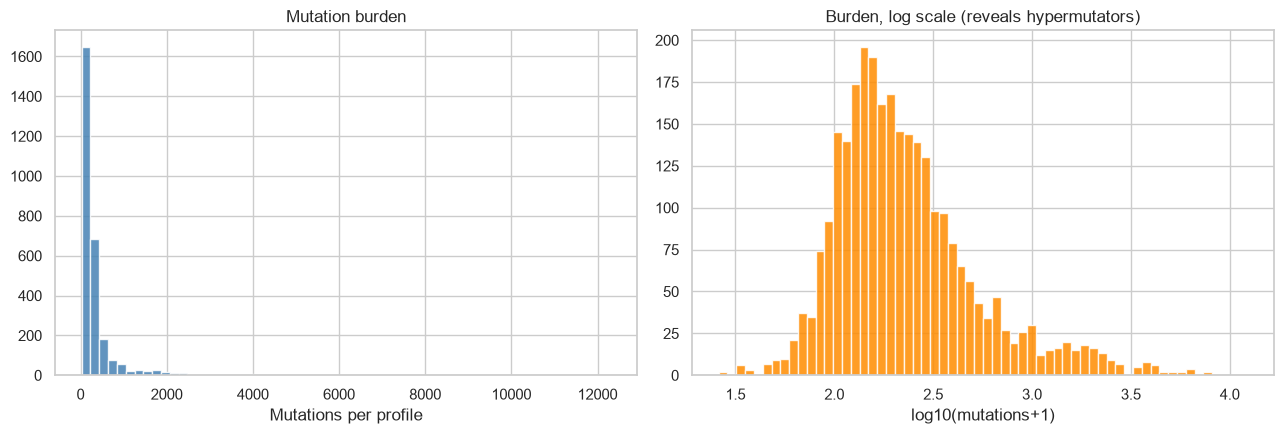

Median burden/profile: 194   Hypermutators (>10k): 1


In [4]:
burden = df.groupby('ProfileID').size()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(burden, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Mutations per profile'); axes[0].set_title('Mutation burden')
axes[1].hist(np.log10(burden + 1), bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('log10(mutations+1)'); axes[1].set_title('Burden, log scale (reveals hypermutators)')
plt.tight_layout(); plt.show()
print(f"Median burden/profile: {burden.median():.0f}   Hypermutators (>10k): {(burden > 10000).sum()}")

### Why this EDA check matters

A hypermutated line will show many incidental mutations near any query gene by chance alone — high
raw mutation count near a gene is not itself evidence the gene is a functional driver in that line,
which is exactly why `HessDriver` (curated), not raw count, is the flag to score against.

## 3. VepImpact distribution and driver flags

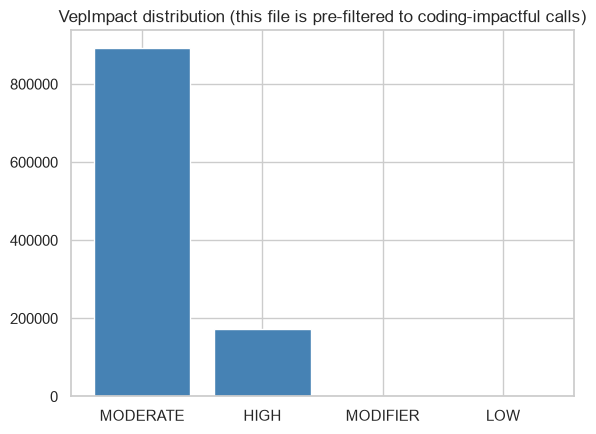

VepImpact
MODERATE    892565
HIGH        173751
MODIFIER       514
LOW             39
Name: count, dtype: int64


In [5]:
vep = df['VepImpact'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(vep.index, vep.values, color='steelblue')
ax.set_title('VepImpact distribution (this file is pre-filtered to coding-impactful calls)')
plt.tight_layout(); plt.show()
print(vep)

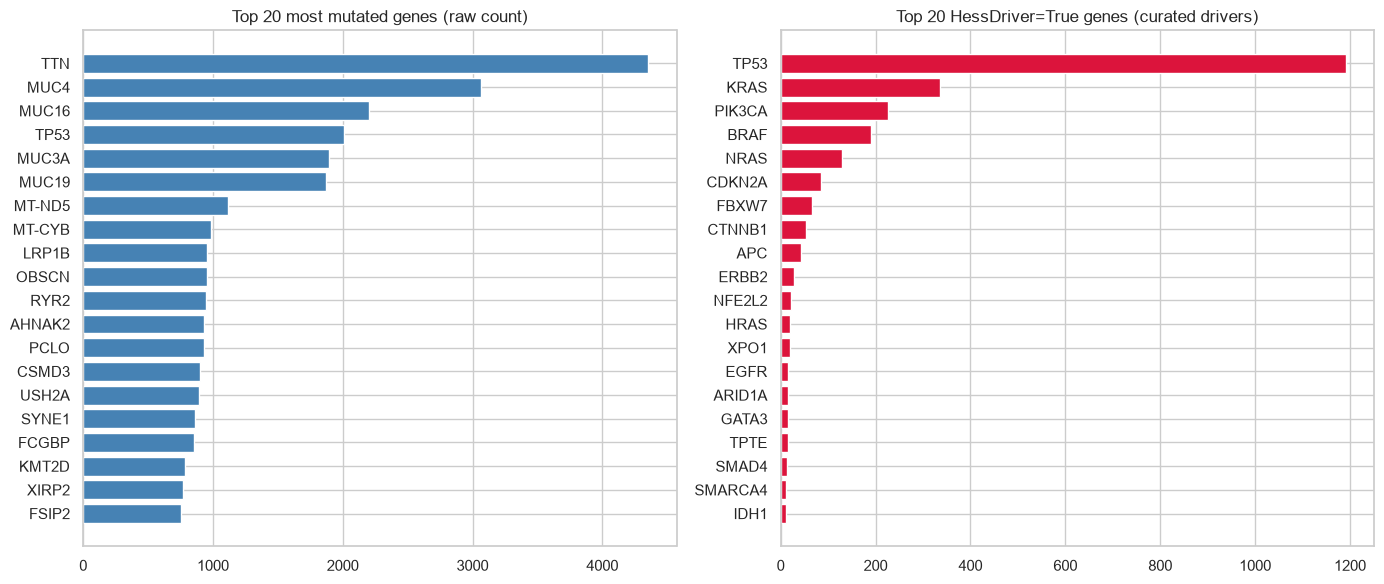

In [6]:
top_raw = df['HugoSymbol'].value_counts().head(20)
top_driver = df[df['HessDriver'] == True]['HugoSymbol'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_raw.index[::-1], top_raw.values[::-1], color='steelblue')
axes[0].set_title('Top 20 most mutated genes (raw count)')
axes[1].barh(top_driver.index[::-1], top_driver.values[::-1], color='crimson')
axes[1].set_title('Top 20 HessDriver=True genes (curated drivers)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

This is the direct evidence for the trap named in `data/raw/_.md`: raw mutation count is dominated
by large genes that simply accumulate more passenger mutations by chance, while `HessDriver` surfaces
a smaller, biologically curated set. The scorer must use `HessDriver`, not raw frequency or
`OncogeneHighImpact` alone, to call a gene mutated in the driver sense.

## 4. Driver burden and the MSI link (cross-check with file 14)

Microsatellite-instable (MSI-high) lines have defective DNA mismatch repair and are expected to
be **hypermutated** as a downstream consequence. Checking this known relationship against file 14's
`MSIScore` is a biological sanity check on whether burden in this table means what it should.

Driver genes per profile: median 1, max 46


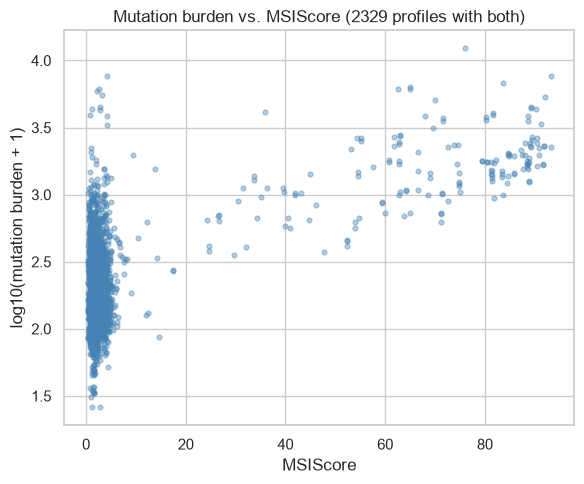

Spearman correlation: 0.18


In [7]:
driver_count = df[df['HessDriver'] == True].groupby('ProfileID')['HugoSymbol'].nunique()
print(f"Driver genes per profile: median {int(driver_count.median())}, max {int(driver_count.max())}")

df8 = pd.read_csv(NOMENCLATURE / '8_DepMap_OmicsProfiles.csv', usecols=['ProfileID', 'ModelID'])
df14 = pd.read_csv(NON_GENE_EXPRESSION / '14_OmicsGlobalSignatures.csv',
                    usecols=['ModelID', 'MSIScore', 'IsDefaultEntryForModel'])
msi = df14[df14['IsDefaultEntryForModel'] == 'Yes'].set_index('ModelID')['MSIScore']
profile_to_model = df8.drop_duplicates('ProfileID').set_index('ProfileID')['ModelID']

b = burden.rename('burden').to_frame()
b['MSIScore'] = b.index.map(profile_to_model).map(msi)
b = b.dropna(subset=['MSIScore'])

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(b['MSIScore'], np.log10(b['burden'] + 1), alpha=0.4, s=12, color='steelblue')
ax.set_xlabel('MSIScore'); ax.set_ylabel('log10(mutation burden + 1)')
ax.set_title(f'Mutation burden vs. MSIScore ({len(b)} profiles with both)')
plt.tight_layout(); plt.show()
print(f"Spearman correlation: {b['MSIScore'].corr(b['burden'], method='spearman'):.2f}")

### Why this EDA check matters

A positive correlation here is the expected biology (MSI-high → hypermutation) and is evidence this
table's burden signal is trustworthy, not an artefact of sequencing depth alone. **Correlation
only** — this does not establish that MSI status *causes* every individual line's burden level, per
root `_.md` §3, and a future cross-layer notebook (not this one) is where a properly lineage-adjusted
version of this check belongs.

## 5. Identity join path to the primary spine

In [8]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'lineage'])
mut_profiles = set(df['ProfileID'].dropna())
df8_seq = pd.read_csv(NOMENCLATURE / '8_DepMap_OmicsProfiles.csv', usecols=['ProfileID', 'ModelID', 'Datatype'])
df8_seq = df8_seq[df8_seq['Datatype'].isin(['wes', 'wgs'])]

matched_profiles = mut_profiles & set(df8_seq['ProfileID'])
resolved_models = set(df8_seq[df8_seq['ProfileID'].isin(matched_profiles)]['ModelID'])
matched_models = resolved_models & set(df9['DepMap_ID'])

print(f"Mutation-call profiles (this table)     : {len(mut_profiles)}")
print(f"Hop 1 -> file 8 (Datatype in wes/wgs)    : {len(matched_profiles)} ({len(matched_profiles)/len(mut_profiles):.1%})")
print(f"Hop 2 -> file 9 (reaches primary spine)  : {len(matched_models)} ({len(matched_models)/len(resolved_models):.1%} of resolved models)")

Mutation-call profiles (this table)     : 2828
Hop 1 -> file 8 (Datatype in wes/wgs)    : 2329 (82.4%)
Hop 2 -> file 9 (reaches primary spine)  : 1697 (97.3% of resolved models)


### Why this EDA check matters

Some cell lines carry both WES and WGS profiles — file 8 filtered to `Datatype in {wes, wgs}` can
resolve more than one profile per model, the same default-profile selection issue notebook 02 and
05 flagged, here for a different assay pair.

## 6. Coverage bias by lineage

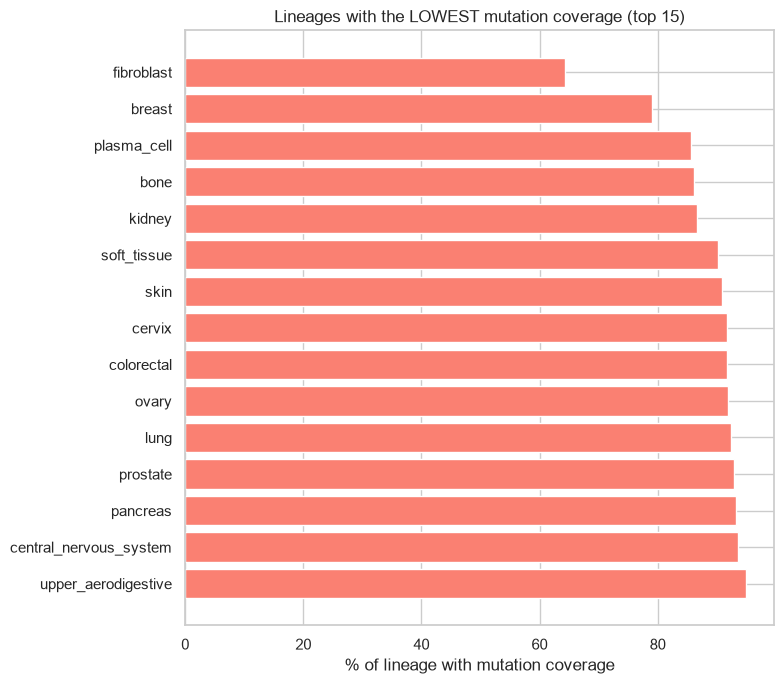

In [9]:
covered = df9[df9['DepMap_ID'].isin(matched_models)]
total_per_lineage = df9['lineage'].value_counts()
covered_per_lineage = covered['lineage'].value_counts()
coverage_pct = (covered_per_lineage / total_per_lineage * 100).dropna().sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
bottom15 = coverage_pct.head(15)
ax.barh(bottom15.index[::-1], bottom15.values[::-1], color='salmon')
ax.set_xlabel('% of lineage with mutation coverage')
ax.set_title('Lineages with the LOWEST mutation coverage (top 15)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Same disclosure requirement as every other layer: mutation coverage must be reported per lineage,
not as one overall percentage, before this layer can pass `docs/PROJECT_ARCHITECTURE.md` §6's A2
criterion.

## Decisions carried into the next notebooks

1. **Use `HessDriver == True` for driver-mutation calls — never raw mutation count or
   `OncogeneHighImpact`/`TumorSuppressorHighImpact` alone**, which miss hotspot mutations like
   KRAS G12 (§3).
2. Mutation burden must be judged in context of the MSI/hypermutation relationship (§4) — a high
   raw burden near a query gene is weak evidence on its own in a hypermutated line.
3. **Resolve to a default profile per model before any per-line score** — WES/WGS multiplicity
   (§5) can duplicate a line the same way RNA and fusion profiles could.
4. Coverage is lineage-biased (§6) — disclose per lineage.
5. **Limitation:** the MSI-burden correlation in §4 is unadjusted for lineage; a real driver-burden
   conclusion needs the lineage-stratified version a cross-layer notebook will build later.